 Generate historical events for the full date range:

In [1]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
from datetime import datetime, timedelta

sys.path.insert(0, str(Path.cwd().parent))

from feature_store.sources.events import generate_boston_events, events_to_features

BOSTON_DATA = Path(r"C:\Users\syeds\OneDrive\Desktop\nboracle\nb_oracle\data\raw\boston-bodega")

# Generate events for entire dataset period
start_date = "2024-01-01"
yesterday = (datetime.now() - timedelta(days=1)).strftime("%Y-%m-%d")

events = generate_boston_events(start_date, yesterday, seed=42)

print(f"Generated {len(events)} events from {start_date} to {yesterday}")
print(f"\nEvent breakdown:")
print(events["category"].value_counts().to_string())
print(f"\nImpact type breakdown:")
print(events["impact_type"].value_counts().to_string())
print(f"\nSample events:")
print(events.head(10).to_string(index=False))

Generated 713 events from 2024-01-01 to 2026-03-02

Event breakdown:
category
sports       558
music         96
community     59

Impact type breakdown:
impact_type
city_draw_away    626
nearby_boost       87

Sample events:
      date                      name            venue  category  attendance_est  distance_miles    impact_type
2024-01-02         Celtics Home Game        TD Garden    sports           18330             4.5 city_draw_away
2024-01-03          Bruins Home Game        TD Garden    sports           17343             4.5 city_draw_away
2024-01-04         Celtics Home Game        TD Garden    sports           18276             4.5 city_draw_away
2024-01-05 School Event at Henderson Henderson School community             544             0.8   nearby_boost
2024-01-05         Celtics Home Game        TD Garden    sports           19082             4.5 city_draw_away
2024-01-05 Concert at House of Blues   House of Blues     music            2475             4.0 city_draw_awa

Convert to daily features:


In [2]:
all_dates = pd.date_range(start_date, yesterday)
event_features = events_to_features(events, all_dates)

print(f"Event features: {len(event_features)} days")
print(f"\nColumns: {list(event_features.columns)}")
print(f"\nSample (days WITH events):")
has_events = event_features[event_features["nearby_events"] > 0].head(10)
print(has_events.to_string(index=False))

print(f"\nEvent stats:")
print(f"  Days with nearby events: {(event_features['nearby_events'] > 0).sum()} ({(event_features['nearby_events'] > 0).mean()*100:.1f}%)")
print(f"  Days with city events: {(event_features['city_events'] > 0).sum()} ({(event_features['city_events'] > 0).mean()*100:.1f}%)")
print(f"  Days with marathon: {(event_features['is_marathon'] > 0).sum()}")

# Save for later use
event_features.to_csv(BOSTON_DATA / "events_features.csv", index=False)
print(f"\nSaved to {BOSTON_DATA / 'events_features.csv'}")

Event features: 792 days

Columns: ['date', 'nearby_events', 'nearby_attendance', 'city_events', 'city_attendance', 'has_sports_nearby', 'has_sports_city', 'has_music', 'is_marathon', 'event_score']

Sample (days WITH events):
      date  nearby_events  nearby_attendance  city_events  city_attendance  has_sports_nearby  has_sports_city  has_music  is_marathon  event_score
2024-01-05              1                544            2            21557                  0                1          1            0        -0.10
2024-01-08              1                288            0                0                  0                0          0            0         0.29
2024-01-23              1                378            1            18742                  0                1          0            0        -0.18
2024-02-23              1                371            0                0                  0                0          0            0         0.37
2024-03-15              1        

Regenerate sales data WITH event influence

In [3]:
import requests

# Load existing weather
weather = pd.read_csv(BOSTON_DATA / "weather_boston.csv", parse_dates=["date"])
weather_lookup = {row["date"].date(): row for _, row in weather.iterrows()}

# Load events for lookup
events_lookup = {}
for _, row in event_features.iterrows():
    events_lookup[pd.Timestamp(row["date"]).date()] = row

# Same categories as before
CATEGORIES = {
    "AUTOMOTIVE": (3, 2), "BABY CARE": (5, 3), "BEAUTY": (8, 4),
    "BEVERAGES": (120, 35), "BOOKS": (2, 2), "BREAD/BAKERY": (65, 20),
    "CELEBRATION": (4, 3), "CLEANING": (25, 10), "DAIRY": (80, 25),
    "DELI": (30, 12), "EGGS": (40, 15), "FROZEN FOODS": (20, 8),
    "GROCERY I": (150, 40), "GROCERY II": (15, 7), "HARDWARE": (3, 2),
    "HOME AND KITCHEN I": (8, 5), "HOME AND KITCHEN II": (5, 3),
    "HOME APPLIANCES": (2, 2), "HOME CARE": (12, 6), "LADIESWEAR": (4, 3),
    "LAWN AND GARDEN": (3, 2), "LINGERIE": (3, 2),
    "LIQUOR,WINE,BEER": (35, 15), "MAGAZINES": (2, 2), "MEATS": (45, 18),
    "PERSONAL CARE": (18, 8), "PET SUPPLIES": (6, 4),
    "PLAYERS AND ELECTRONICS": (3, 2), "POULTRY": (35, 14),
    "PREPARED FOODS": (25, 10), "PRODUCE": (90, 30),
    "SCHOOL AND OFFICE SUPPLIES": (4, 3), "SEAFOOD": (15, 8),
}

np.random.seed(42)
dates = pd.date_range(start_date, yesterday)
records = []
row_id = 0

for date in dates:
    dt = pd.Timestamp(date)
    dow = dt.dayofweek
    month = dt.month
    day = dt.day
    day_of_year = dt.dayofyear
    
    # Get weather
    w = weather_lookup.get(dt.date(), None)
    temp = w["temp_high"] if w is not None else 65
    precip = w["precipitation_mm"] if w is not None else 0
    snow = w.get("snow_mm", 0) if w is not None else 0
    
    # Get events
    ev = events_lookup.get(dt.date(), None)
    nearby_attendance = ev["nearby_attendance"] if ev is not None else 0
    city_attendance = ev["city_attendance"] if ev is not None else 0
    is_marathon = ev["is_marathon"] if ev is not None else 0
    event_score = ev["event_score"] if ev is not None else 0
    
    # ── Global multipliers ───────────────────────────────────
    dow_mult = {0: 0.85, 1: 0.88, 2: 0.90, 3: 0.92, 4: 1.05, 5: 1.20, 6: 1.10}[dow]
    payday_mult = 1.15 if day in [1, 2, 15, 16] else 1.0
    
    if snow > 10: traffic_mult = 0.5
    elif snow > 2: traffic_mult = 0.75
    elif precip > 15: traffic_mult = 0.8
    elif precip > 5: traffic_mult = 0.9
    else: traffic_mult = 1.0
    
    days_from_start = (dt - dates[0]).days
    trend_mult = 1 + (days_from_start / 365) * 0.02
    
    # ── EVENT MULTIPLIER (NEW) ───────────────────────────────
    # Nearby events boost sales
    if nearby_attendance > 0:
        nearby_mult = 1 + min(nearby_attendance / 5000, 0.40)  # Up to 40% boost
    else:
        nearby_mult = 1.0
    
    # City events slightly reduce traffic (people go elsewhere)
    if city_attendance > 20000:
        city_mult = 0.95  # 5% reduction for big city events
    elif city_attendance > 10000:
        city_mult = 0.97  # 3% reduction
    else:
        city_mult = 1.0
    
    # Marathon is a huge boost
    if is_marathon:
        nearby_mult = 1.50  # 50% boost on marathon day
    
    for family, (base_mean, base_std) in CATEGORIES.items():
        
        # Category-specific weather effects (same as before)
        weather_mult = 1.0
        if family in ["BEVERAGES", "FROZEN FOODS"]:
            if temp > 85: weather_mult = 1.35
            elif temp > 75: weather_mult = 1.15
            elif temp < 35: weather_mult = 0.85
        elif family in ["PREPARED FOODS", "BREAD/BAKERY"]:
            if temp < 35: weather_mult = 1.25
            elif temp < 50: weather_mult = 1.10
            elif temp > 85: weather_mult = 0.90
        elif family in ["LIQUOR,WINE,BEER"]:
            if temp > 70 and dow >= 4: weather_mult = 1.30
            elif temp > 70: weather_mult = 1.10
        elif family in ["PRODUCE", "DAIRY", "EGGS"]:
            weather_mult = 1 + 0.05 * np.sin(2 * np.pi * (day_of_year - 90) / 365)
        elif family in ["CLEANING", "HOME CARE"]:
            if month in [3, 4, 5]: weather_mult = 1.15
        elif family in ["SCHOOL AND OFFICE SUPPLIES"]:
            if month in [8, 9]: weather_mult = 2.5
            elif month == 1: weather_mult = 1.5
        elif family in ["CELEBRATION"]:
            if month == 12: weather_mult = 3.0
            elif month in [2, 10]: weather_mult = 2.0
        
        # Seasonal
        if family == "LAWN AND GARDEN":
            seasonal_mult = 2.0 if month in [4, 5, 6, 7, 8] else 0.3
        elif family == "SEAFOOD" and month in [2, 3, 4] and dow == 4:
            seasonal_mult = 1.8
        else:
            seasonal_mult = 1.0
        
        # Category-specific event effects
        event_cat_mult = 1.0
        if family in ["BEVERAGES", "LIQUOR,WINE,BEER", "GROCERY I"] and nearby_attendance > 0:
            event_cat_mult = 1.10  # Extra 10% boost for drinks/snacks near events
        
        # Promotions
        on_promo = 1 if np.random.random() < 0.15 else 0
        promo_mult = 1.20 if on_promo else 1.0
        
        # Final calculation — now includes event multipliers
        total_mult = (dow_mult * payday_mult * traffic_mult * trend_mult *
                     weather_mult * seasonal_mult * promo_mult *
                     nearby_mult * city_mult * event_cat_mult)
        
        raw_sales = base_mean * total_mult + np.random.normal(0, base_std)
        sales = max(0, round(raw_sales))
        
        records.append({
            "id": row_id,
            "date": dt.strftime("%Y-%m-%d"),
            "store_nbr": 1,
            "family": family,
            "sales": sales,
            "onpromotion": on_promo,
        })
        row_id += 1

train_df = pd.DataFrame(records)
print(f"Regenerated {len(train_df):,} sales records WITH event influence")

Regenerated 26,136 sales records WITH event influence


save the updated data

In [4]:
# Overwrite the old train.csv with event-influenced version
train_df.to_csv(BOSTON_DATA / "train.csv", index=False)
print(f"✅ Saved updated train.csv to {BOSTON_DATA}")

# Verify: compare sales on event days vs non-event days
bev = train_df[train_df.family == "BEVERAGES"].copy()
bev["date"] = pd.to_datetime(bev["date"])
bev = bev.merge(event_features[["date", "nearby_events", "city_events", "event_score"]], on="date", how="left")

print(f"\nBeverage sales comparison:")
print(f"  Days with nearby events:    avg {bev[bev.nearby_events > 0]['sales'].mean():.0f} units")
print(f"  Days without nearby events: avg {bev[bev.nearby_events == 0]['sales'].mean():.0f} units")
print(f"  Difference:                 {bev[bev.nearby_events > 0]['sales'].mean() - bev[bev.nearby_events == 0]['sales'].mean():+.0f} units")

print(f"\n  Days with city events:      avg {bev[bev.city_events > 0]['sales'].mean():.0f} units")
print(f"  Days without city events:   avg {bev[bev.city_events == 0]['sales'].mean():.0f} units")
print(f"  Difference:                 {bev[bev.city_events > 0]['sales'].mean() - bev[bev.city_events == 0]['sales'].mean():+.0f} units")

✅ Saved updated train.csv to C:\Users\syeds\OneDrive\Desktop\nboracle\nb_oracle\data\raw\boston-bodega

Beverage sales comparison:
  Days with nearby events:    avg 162 units
  Days without nearby events: avg 126 units
  Difference:                 +36 units

  Days with city events:      avg 127 units
  Days without city events:   avg 134 units
  Difference:                 -6 units


Train the model WITH event features and compare

In [5]:
import xgboost as xgb
from feature_store.engineer import build_features, get_feature_columns
from model.evaluate import compute_wmape

holidays = pd.read_csv(BOSTON_DATA / "holidays_events.csv", parse_dates=["date"])
weather_pipeline = pd.read_csv(BOSTON_DATA / "weather_pipeline.csv", parse_dates=["date"])

store1 = train_df[train_df.store_nbr == 1].copy()
store1["date"] = pd.to_datetime(store1["date"])
bev_data = store1[store1.family == "BEVERAGES"].sort_values("date").reset_index(drop=True)

SPLIT_DATE = (pd.Timestamp(yesterday) - pd.Timedelta(days=30)).strftime("%Y-%m-%d")

# === Model WITHOUT events ===
features_no_events = build_features(bev_data, holidays, weather_df=weather_pipeline).dropna()
fc_no = get_feature_columns(features_no_events)
tr_no = features_no_events[features_no_events.index < SPLIT_DATE]
te_no = features_no_events[features_no_events.index >= SPLIT_DATE]

model_no = xgb.XGBRegressor(
    objective="reg:tweedie", tweedie_variance_power=1.6,
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7, min_child_weight=10,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42,
    early_stopping_rounds=30)
model_no.fit(tr_no[fc_no], tr_no["sales"],
             eval_set=[(te_no[fc_no], te_no["sales"])], verbose=False)
pred_no = np.maximum(model_no.predict(te_no[fc_no]), 0)
wmape_no = compute_wmape(te_no["sales"].values, pred_no)

# === Model WITH events ===
features_with_events = build_features(bev_data, holidays, 
                                       weather_df=weather_pipeline,
                                       events_df=event_features).dropna()
fc_ev = get_feature_columns(features_with_events)
tr_ev = features_with_events[features_with_events.index < SPLIT_DATE]
te_ev = features_with_events[features_with_events.index >= SPLIT_DATE]

model_ev = xgb.XGBRegressor(
    objective="reg:tweedie", tweedie_variance_power=1.6,
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7, min_child_weight=10,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42,
    early_stopping_rounds=30)
model_ev.fit(tr_ev[fc_ev], tr_ev["sales"],
             eval_set=[(te_ev[fc_ev], te_ev["sales"])], verbose=False)
pred_ev = np.maximum(model_ev.predict(te_ev[fc_ev]), 0)
wmape_ev = compute_wmape(te_ev["sales"].values, pred_ev)

# Baseline
baseline_pred = te_ev["sales_same_dow_avg_4w"].fillna(0).values
wmape_baseline = compute_wmape(te_ev["sales"].values, baseline_pred)

print("=" * 60)
print("  BOSTON BODEGA — Beverages — Event Impact")
print("=" * 60)
print(f"  Baseline (4-week avg):     {wmape_baseline:.1%}")
print(f"  XGBoost (weather only):    {wmape_no:.1%}")
print(f"  XGBoost (weather+events):  {wmape_ev:.1%}")
print("=" * 60)

if wmape_ev < wmape_no:
    improve = (wmape_no - wmape_ev) / wmape_no * 100
    print(f"  ✅ Events improved the model by {improve:.1f}%!")
else:
    print(f"  ⚠️ Events didn't help for this test period")

  BOSTON BODEGA — Beverages — Event Impact
  Baseline (4-week avg):     44.4%
  XGBoost (weather only):    33.7%
  XGBoost (weather+events):  35.9%
  ⚠️ Events didn't help for this test period


See which event features the model uses:

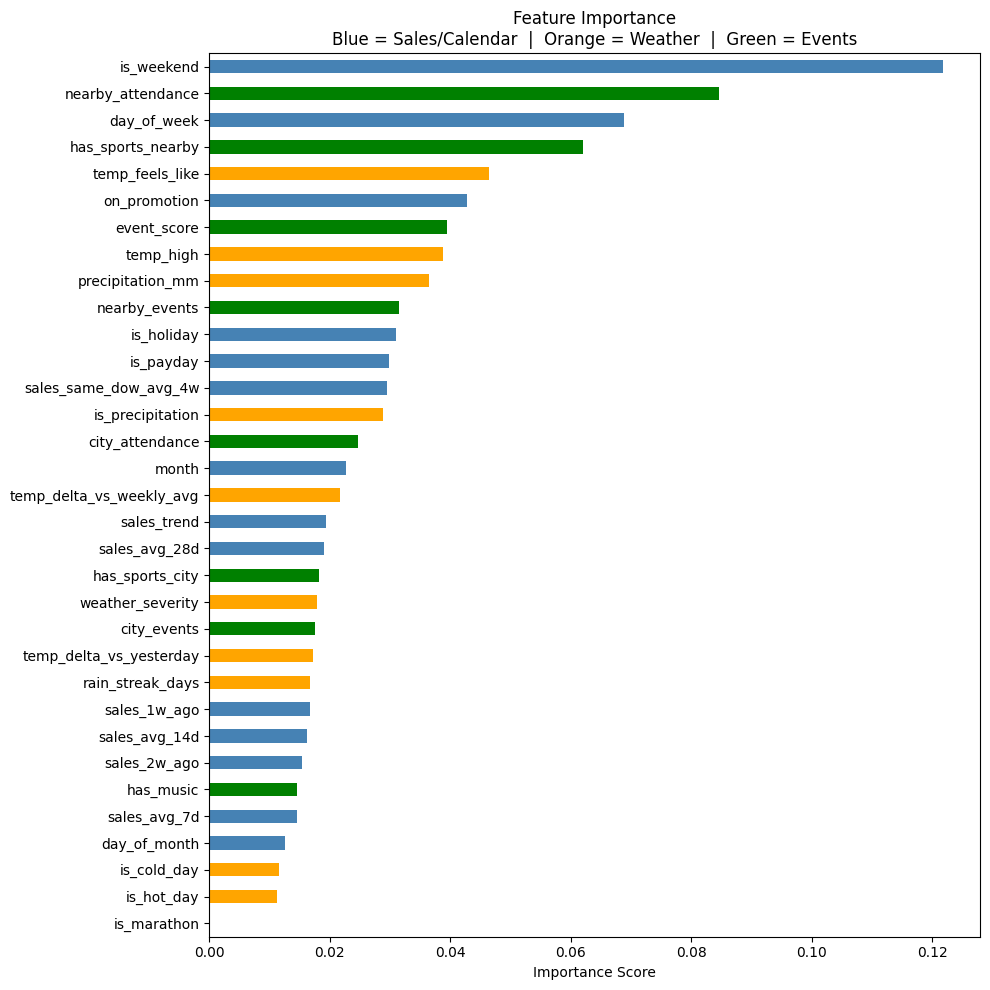


Event feature importance:
  • nearby_events: 0.0315
  • nearby_attendance: 0.0846
  • city_events: 0.0175
  • city_attendance: 0.0246
  • has_sports_nearby: 0.0620
  • has_sports_city: 0.0182
  • has_music: 0.0146
  • is_marathon: 0.0000
  • event_score: 0.0395


In [6]:
import matplotlib.pyplot as plt

importance = pd.Series(
    model_ev.feature_importances_, index=fc_ev
).sort_values(ascending=True)

event_feats = ["nearby_events", "nearby_attendance", "city_events",
               "city_attendance", "has_sports_nearby", "has_sports_city",
               "has_music", "is_marathon", "event_score"]
weather_feats = ["temp_high", "temp_feels_like", "is_precipitation",
                 "precipitation_mm", "temp_delta_vs_yesterday",
                 "temp_delta_vs_weekly_avg", "weather_severity",
                 "is_hot_day", "is_cold_day", "rain_streak_days"]

def get_color(feat):
    if feat in event_feats:
        return "green"
    elif feat in weather_feats:
        return "orange"
    else:
        return "steelblue"

colors = [get_color(f) for f in importance.index]

fig, ax = plt.subplots(figsize=(10, 10))
importance.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Feature Importance\nBlue = Sales/Calendar  |  Orange = Weather  |  Green = Events")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nEvent feature importance:")
for f in event_feats:
    if f in importance:
        print(f"  • {f}: {importance[f]:.4f}")